In [1]:
import time
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(100000)

def quick_sort(arr, low, high):

    if low < high:

        pi = partition(arr, low, high)

        quick_sort(arr, low, pi - 1)
        quick_sort(arr, pi + 1, high)


def partition(arr, low, high):

    pivot = arr[high]

    i = low - 1

    for j in range(low, high):

        if arr[j] <= pivot:

            i += 1
            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1



# Best-case input generator


def generate_best_case(n):

    arr = list(range(1, n + 1))

    def arrange(low, high):

        if low >= high:
            return

        mid = (low + high) // 2

        # Put the median at the end
        arr[mid], arr[high] = arr[high], arr[mid]

        # Recursively arrange the two halves
        arrange(low, mid - 1)
        arrange(mid + 1, high)

    arrange(0, n - 1)

    return arr



sizes = list(range(100, 3001, 200))

best_times = []
worst_times = []

runs = 10


for n in sizes:

    # Best-case input
    best_array = generate_best_case(n)

    # Worst-case input
    worst_array = list(range(1, n + 1))

    best_measurements = []
    worst_measurements = []

    for _ in range(runs):

        # Copy so the original input remains unchanged
        arr = best_array.copy()

        start = time.perf_counter_ns()

        quick_sort(arr, 0, n - 1)

        end = time.perf_counter_ns()

        best_measurements.append(end - start)


        # Worst case
        arr = worst_array.copy()

        start = time.perf_counter_ns()

        quick_sort(arr, 0, n - 1)

        end = time.perf_counter_ns()

        worst_measurements.append(end - start)

    best_times.append(sum(best_measurements) / runs)
    worst_times.append(sum(worst_measurements) / runs)




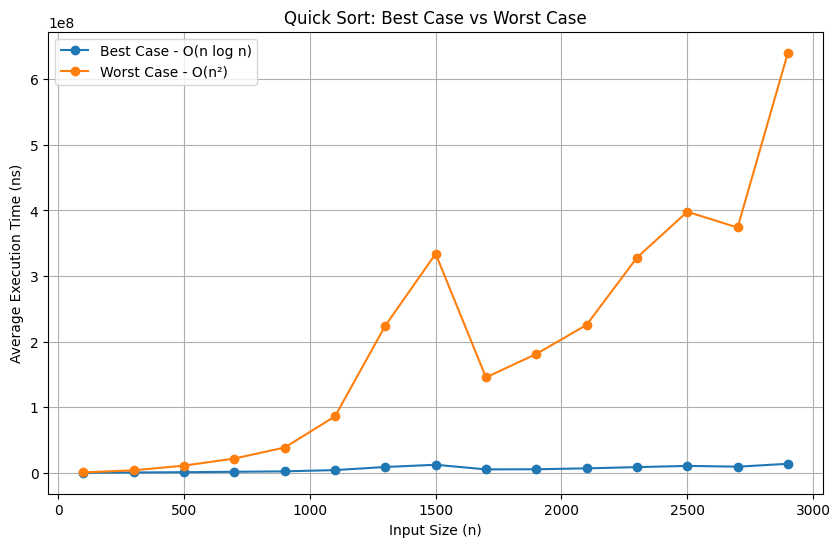

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    best_times,
    marker='o',
    label='Best Case - O(n log n)'
)

plt.plot(
    sizes,
    worst_times,
    marker='o',
    label='Worst Case - O(n²)'
)

plt.title("Quick Sort: Best Case vs Worst Case")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Execution Time (ns)")
plt.legend()
plt.grid(True)

plt.show()